**pandas** is a Python package to wrangle and analyze tabular data. It is built on top of NumPy and has become the core tool for doing data analysis in Python. 

The standard abbreviation for **pandas** is **pd**. Here we will import it together with NumpPy:

In [4]:
import numpy as np 
import pandas as pd

## Series 

The first core object of pandas is the **series**. A series is a *one-dimensional* array of *indexed* data. 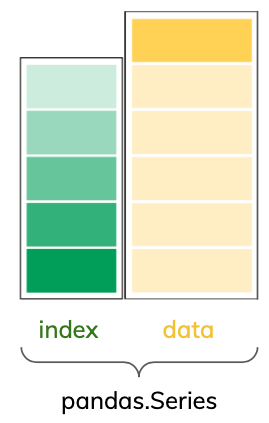

A `pandas.Series` having an **index** is the main difference between a `pandas.Series` and a NumPy array. Let's see the difference 

In [4]:
# A numpy array 
arr = np.random.randn(4) # random values from std normal distribution 
print(type(arr))
print(arr, "\n")

# A pandas series made from the previous arrat 
s = pd.Series(arr)
print(type(s))
print(s)

<class 'numpy.ndarray'>
[ 0.89707871 -0.49064843 -1.72171662 -0.23958213] 

<class 'pandas.core.series.Series'>
0    0.897079
1   -0.490648
2   -1.721717
3   -0.239582
dtype: float64


Notice the index is printed as part of the `pandas.Series` while, although the `np.array` is indexable, the index is not part of this data structure. Printing the `pandas.Series` also shows the values and their data type. 

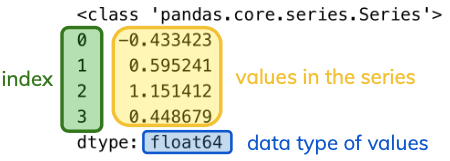

## Creating a `pandas.Series`

The basic method to create a `pandas.Series` is to call

In [3]:
s = pd.Series(data, index=index)

NameError: name 'data' is not defined

The `data` parameter can be: 

- a list or NumPy array,
- a Python dictionary, or
- a single number, boolean (`True/False`,) or string.

The `index` parameter is optional. If we wish to include it, it must be a list of indices of the same length as `data`. 

Example: Creating a `pandas.Series` from a NumPy array

Let's create a `pandas.Series` from a NumPy array. To use this method we need to pass a NumPy array (or a list of objects that can be converted to NumPy types) as `data`. Here, we will also include the list `[2023, 2024, 2025]` to be used as an index:

In [4]:
# A series from a numpy array 
pd.Series(np.arange(3), index = [2023, 2024, 2025])

2023    0
2024    1
2025    2
dtype: int64

### Example: Creating a `pandas.Series` from a list 

Here we create a `pandas.Series` from a list of strings. Remember that the `index` parameter is optional. If we don't include it, the default is to make the index equal to `[0,...,len(data-1)]. For example: 

In [5]:
# A series from a list of strings with default index
pd.Series(['EDS 220', 'EDS 222', 'EDS 223', 'EDS 242'])

0    EDS 220
1    EDS 222
2    EDS 223
3    EDS 242
dtype: object

### Example: Creating a `pandas.Series` from a dictionary 

Recall that a dictionary is a set of key-value pairs. If we create a `pandas.Series` via a dictionary the keys will become the index and the values the corresponding data. 

In [6]:
# Construct dictionary 
d = {'key_0': 2, 'key_1': 3, 'key_2': 5}

# Initialize series using a dictionary 
pd.Series(d)

key_0    2
key_1    3
key_2    5
dtype: int64

### Example: Creating a `pandas.Series` from a single value 

If we only provide a single number, boolean, or string as the data for the series, we need to provide an index. The value will be repeated to match the length of the index. Here, we create a series from a single float number with an index given by a list of strings:

In [8]:
pd.Series(3.0, index = ['A', 'B', 'C'])

A    3.0
B    3.0
C    3.0
dtype: float64

### Simple Operations

Arithmetic operations work on series and so do most NumPy functions. For example: 

In [9]:
# Define a series 
s = pd.Series([98, 73, 65], index=['Andrea', 'Beth', 'Carolina'])

# Divide each element in series by 10 
print(s / 10, '\n')

# Take the exponential of each element in series 
print(np.exp(s), '\n')

# Original series is unchanged 
print(s)

Andrea      9.8
Beth        7.3
Carolina    6.5
dtype: float64 

Andrea      3.637971e+42
Beth        5.052394e+31
Carolina    1.694889e+28
dtype: float64 

Andrea      98
Beth        73
Carolina    65
dtype: int64


We can also produce new `pandas.Series` with `True/False` values indicating whether the elements in a series satisfy a condition or not:

In [10]:
s > 70 

Andrea       True
Beth         True
Carolina    False
dtype: bool

This kind of simple conditions on `pandas.Series` will be key when we are selecting data from data frames. 


## Identifying missing values 

In `pandas` we can represent a missing NULL or NA value with the float value numpy.nan, which stands for "not a number." Let's construct a small series with some NA values represented this way: 

In [11]:
# Series with NAs in it 
s = pd.Series([1, 2, np.nan, 4, np.nan])
s 

0    1.0
1    2.0
2    NaN
3    4.0
4    NaN
dtype: float64

Notice the data type of the values in the series is still `float64`.

The hasnans attribute for a `pandas.Series` returns `True` if there are any NA values in it and `False` otherwise:

In [12]:
# Check if series has NAs
s.hasnans

True

In [13]:
s.isna()

0    False
1    False
2     True
3    False
4     True
dtype: bool

### Check-In Assignment 

1. The integer number -999 is often used to represent missing values. Create a pandas.Series named s with four integer values, two of which are -999. The index of this series should be the letters A through D.

2. In the pandas.Series documentation, look for the method mask(). Use this method to update the series s so that the -999 values are replaced by NA values. HINT: check the first example in the method’s documentation.

In [5]:
s = pd.Series([1, -999, 3, -999], index = ['A', 'B', 'C', 'D'])
s

A      1
B   -999
C      3
D   -999
dtype: int64

In [7]:
s.mask(s == -999)

A    1.0
B    NaN
C    3.0
D    NaN
dtype: float64

# Data frames 

The `pandas.DataFrame` is the most used `pandas` object. It represents tabular data annd we can think of it was a spreadsheet. Each column of a `pandas.DataFrame` is a `pandas.Series`.

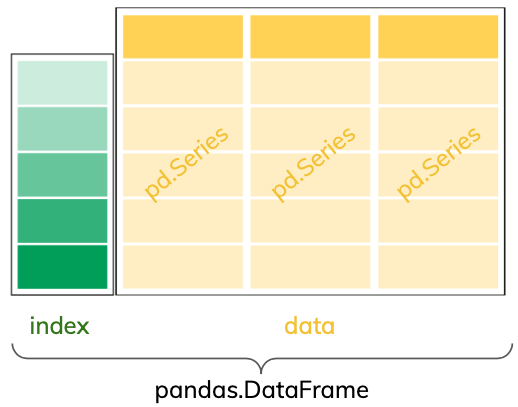

## Creating a `pandas.DataFrame`

There are many ways of creating a pandas.DataFrame. We present one simple one in this section. 

We already mentioend each column of a `pandas.DataFrame` is a `pandas.Series`. In fact, the `pandas.DataFrame` is a dictionary of `pandas.Series`, with each column name bieng the key and the column values being the key's value. Thus, we can create a `pandas.DataFrame` in this way:

In [8]:
# Initialize dictionary with columns' data
d = {'col_name_1' : pd.Series(np.arange(3)),
     'col_name_2' : pd.Series([3.1, 3.2, 3.3]),
}

# Create data frame 
df = pd.DataFrame(d)
df

,col_name_1,col_name_2
0,0,3.1
1,1,3.2
2,2,3.3


We can change the index by changing the `index` attribute in the data frame:

In [10]:
# Change index
df.index = ['a', 'b', 'c']
df

,col_name_1,col_name_2
a,0,3.1
b,1,3.2
c,2,3.3


### Check-In Assignment 

We can access the data frame’s column names via the columns attribute. Update the column names to C1 and C2 by updating this attribute.

In [12]:
df.columns = ['C1', 'C2']
df

,C1,C2
a,0,3.1
b,1,3.2
c,2,3.3
